# 01. Exploración de Datos (EDA)
### California Housing Dataset

**Objetivo:** Entender la naturaleza del dataset, identificar anomalías, rangos y relaciones clave.

| Item | Detalle |
|------|---------|
| **Fuente**  | `data/raw/housing/housing.csv` |
| **Dataset** | California Housing — censo 1990, 20,640 bloques censales |
| **Target**  | `median_house_value` — valor mediano de vivienda (USD) |

---
## 0. Setup

In [38]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# notebooks/ está un nivel abajo de la raíz del proyecto
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 15)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'FIGURES_DIR  : {FIGURES_DIR}')

PROJECT_ROOT : C:\Proyecto\ds-ml-project-template
FIGURES_DIR  : C:\Proyecto\ds-ml-project-template\reports\figures


---
## 1. Carga de Datos

In [39]:
TRAIN_PATH = PROJECT_ROOT / 'data' / 'interim' / 'train_set.csv'

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f'No se encontró: {TRAIN_PATH}\n'
        f'Ejecuta primero:\n'
        f'  python src/data/make_dataset.py\n'
        f'  python src/data/split_data.py'
    )

housing = pd.read_csv(TRAIN_PATH)

print(f'Archivo  : {TRAIN_PATH.name}')
print(f'Filas    : {housing.shape[0]:,}')
print(f'Columnas : {housing.shape[1]}')
print(f'Nombres  : {list(housing.columns)}')

Archivo  : train_set.csv
Filas    : 13,209
Columnas : 10
Nombres  : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


---
## 2. Inspección — Calidad de Datos

| Dimensión | Pregunta clave |
|-----------|----------------|
| **Completitud** | ¿Hay valores faltantes? |
| **Consistencia** | ¿Los tipos y rangos son coherentes? |
| **Precisión** | ¿Hay outliers o valores imposibles? |
| **Sensibilidad** | ¿Hay variables que no se deben usar directamente? |

In [40]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.0800,37.6300,34.0000,1619.0000,293.0000,1148.0000,310.0000,4.0326,164700.0000,NEAR BAY
1,-118.0900,33.9200,35.0000,1994.0000,419.0000,1491.0000,428.0000,3.7383,166200.0000,<1H OCEAN
2,-122.4000,37.7800,32.0000,352.0000,132.0000,313.0000,105.0000,2.5742,350000.0000,NEAR BAY
3,-122.3700,37.9500,35.0000,215.0000,45.0000,100.0000,34.0000,1.6023,81300.0000,NEAR BAY
4,-122.1700,37.7400,43.0000,818.0000,193.0000,494.0000,179.0000,2.4776,101600.0000,NEAR BAY


In [41]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 13209 entries, 0 to 13208
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           13209 non-null  float64
 1   latitude            13209 non-null  float64
 2   housing_median_age  13209 non-null  float64
 3   total_rooms         13209 non-null  float64
 4   total_bedrooms      13071 non-null  float64
 5   population          13209 non-null  float64
 6   households          13209 non-null  float64
 7   median_income       13209 non-null  float64
 8   median_house_value  13209 non-null  float64
 9   ocean_proximity     13209 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.0 MB


In [42]:
housing.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
longitude,13209.0000,-119.5917,2.0021,-124.3500,-123.2092,-122.4600,-121.8100,-118.5200,-118.0100,-117.0800,-116.3108,-114.4900
latitude,13209.0000,35.6525,2.1333,32.5500,32.6708,32.8200,33.9400,34.2700,37.7200,38.9660,40.6000,41.9200
housing_median_age,13209.0000,28.6683,12.5996,1.0000,4.0000,8.0000,18.0000,29.0000,37.0000,52.0000,52.0000,52.0000
total_rooms,13209.0000,2633.5955,2195.1414,8.0000,175.1600,617.0000,1442.0000,2120.0000,3145.0000,6237.4000,11249.4800,39320.0000
total_bedrooms,13071.0000,538.5557,428.0430,1.0000,38.0000,138.0000,295.0000,432.0000,644.0000,1286.0000,2276.6000,6210.0000
population,13209.0000,1421.1790,1101.1552,3.0000,94.0800,346.4000,783.0000,1163.0000,1719.0000,3304.4000,6031.4400,16305.0000
households,13209.0000,499.4001,386.2607,1.0000,32.0000,126.0000,278.0000,407.0000,602.0000,1176.6000,2008.8400,5358.0000
median_income,13209.0000,3.8658,1.8846,0.4999,1.0810,1.6037,2.5625,3.5350,4.7466,7.2978,10.5534,15.0001
median_house_value,13209.0000,206791.8779,115635.4314,14999.0000,49800.0000,65940.0000,118800.0000,179500.0000,264700.0000,492260.0000,500001.0000,500001.0000


In [43]:
# COMPLETITUD — valores faltantes
print('COMPLETITUD')
print('-' * 45)
missing = pd.DataFrame({
    'N faltantes' : housing.isnull().sum(),
    '% faltantes' : (housing.isnull().mean() * 100).round(2),
    'Dtype'       : housing.dtypes,
})
display(missing)
print()
cols_nan = missing[missing['N faltantes'] > 0].index.tolist()
if cols_nan:
    print(f'Columnas con NaN: {cols_nan}')
else:
    print('Sin valores faltantes.')

COMPLETITUD
---------------------------------------------


,N faltantes,% faltantes,Dtype
longitude,0,0.0000,float64
latitude,0,0.0000,float64
housing_median_age,0,0.0000,float64
total_rooms,0,0.0000,float64
total_bedrooms,138,1.0400,float64
population,0,0.0000,float64
households,0,0.0000,float64
median_income,0,0.0000,float64
median_house_value,0,0.0000,float64
ocean_proximity,0,0.0000,str



Columnas con NaN: ['total_bedrooms']


In [44]:
# CONSISTENCIA — duplicados y variable categórica
print('CONSISTENCIA')
print('-' * 45)
print(f'Filas duplicadas : {housing.duplicated().sum()}')
print()
print('ocean_proximity — valores únicos y frecuencias:')
for cat, cnt in housing['ocean_proximity'].value_counts().items():
    pct = cnt / len(housing) * 100
    bar = '█' * (cnt // 200)
    print(f'  {cat:<15}  {cnt:>5,}  ({pct:.1f}%)  {bar}')

CONSISTENCIA
---------------------------------------------
Filas duplicadas : 0

ocean_proximity — valores únicos y frecuencias:
  <1H OCEAN        5,799  (43.9%)  ████████████████████████████
  INLAND           4,238  (32.1%)  █████████████████████
  NEAR OCEAN       1,694  (12.8%)  ████████
  NEAR BAY         1,477  (11.2%)  ███████
  ISLAND               1  (0.0%)  


In [45]:
# PRECISIÓN — outliers por método IQR
print('PRECISIÓN — Outliers (IQR)')
print('-' * 72)
print(f'  {"Variable":<22} {"Q1":>8} {"Q3":>8} {"Límite sup":>11} {"Outliers":>9} {"% total":>8}')
print('  ' + '-' * 68)
for col in housing.select_dtypes(include=np.number).columns:
    Q1  = housing[col].quantile(0.25)
    Q3  = housing[col].quantile(0.75)
    lim = Q3 + 1.5 * (Q3 - Q1)
    n   = (housing[col] > lim).sum()
    pct = n / len(housing) * 100
    flag = '  ← revisar' if pct > 3 else ''
    print(f'  {col:<22} {Q1:>8.1f} {Q3:>8.1f} {lim:>11.1f} {n:>9,} {pct:>7.1f}%{flag}')

PRECISIÓN — Outliers (IQR)
------------------------------------------------------------------------
  Variable                     Q1       Q3  Límite sup  Outliers  % total
  --------------------------------------------------------------------
  longitude                -121.8   -118.0      -112.3         0     0.0%
  latitude                   33.9     37.7        43.4         0     0.0%
  housing_median_age         18.0     37.0        65.5         0     0.0%
  total_rooms              1442.0   3145.0      5699.5       827     6.3%  ← revisar
  total_bedrooms            295.0    644.0      1167.5       854     6.5%  ← revisar
  population                783.0   1719.0      3123.0       783     5.9%  ← revisar
  households                278.0    602.0      1088.0       807     6.1%  ← revisar
  median_income               2.6      4.7         8.0       419     3.2%  ← revisar
  median_house_value     118800.0 264700.0    483550.0       689     5.2%  ← revisar


In [46]:
# SENSIBILIDAD — censura en el target
print('SENSIBILIDAD')
print('-' * 45)
cap_val = housing['median_house_value'].max()
n_cap   = (housing['median_house_value'] == cap_val).sum()
print(f'Valor máximo del target : ${cap_val:,.0f}')
print(f'N registros en ese valor: {n_cap:,} ({n_cap / len(housing) * 100:.1f}%)')
print()
print('El dataset censura precios superiores a $500,001.')
print('Estos registros tienen el mismo valor aunque el precio real sea mayor.')

SENSIBILIDAD
---------------------------------------------
Valor máximo del target : $500,001
N registros en ese valor: 619 (4.7%)

El dataset censura precios superiores a $500,001.
Estos registros tienen el mismo valor aunque el precio real sea mayor.


---
## 3. Histogramas

Distribución de cada variable numérica usando `.hist()`.

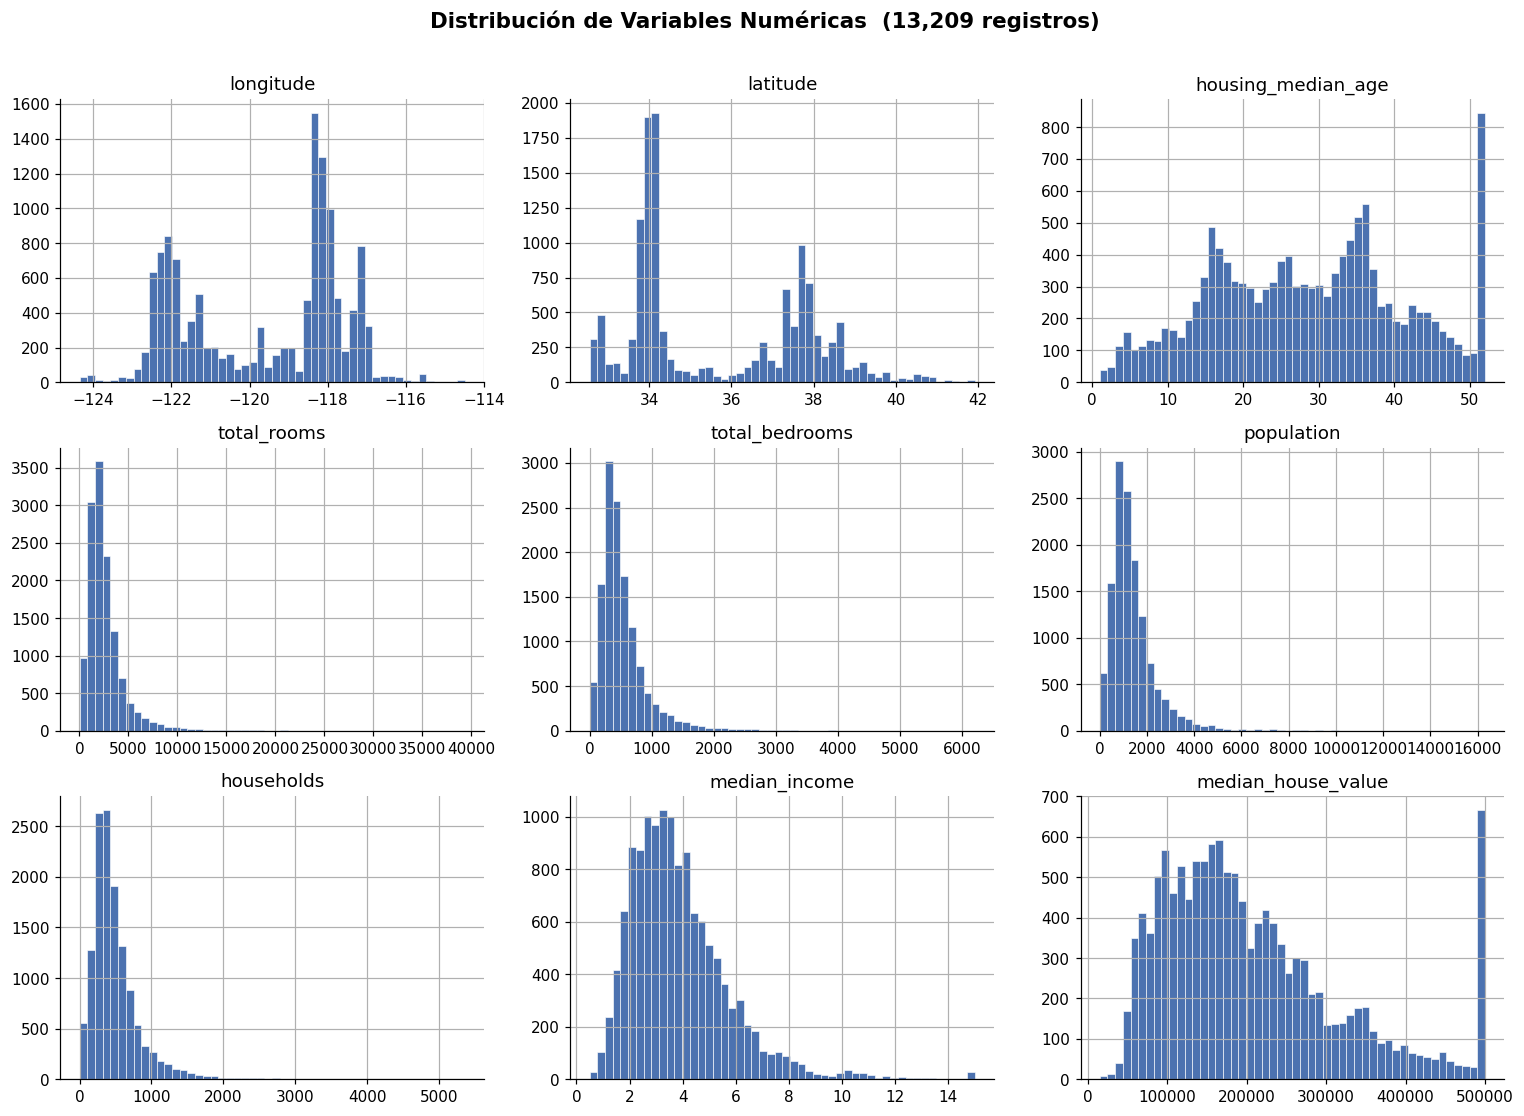


SKEWNESS — |valor| > 1 indica distribución sesgada:
--------------------------------------------------
  total_rooms               +4.257  ← sesgo alto
  total_bedrooms            +3.509  ← sesgo alto
  households                +3.428  ← sesgo alto
  population                +3.354  ← sesgo alto
  median_income             +1.594  ← sesgo alto
  median_house_value        +0.979
  latitude                  +0.435
  housing_median_age        +0.061
  longitude                 -0.276


In [47]:
numeric_cols = housing.select_dtypes(include=np.number).columns.tolist()
n_cols_grid  = 3
n_rows_grid  = (len(numeric_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(14, 10))

housing[numeric_cols].hist(
    bins=50,
    ax=axes.flatten()[:len(numeric_cols)],
    color='#4C72B0',
    edgecolor='white',
    linewidth=0.4,
)

for i in range(len(numeric_cols), len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

fig.suptitle(
    f'Distribución de Variables Numéricas  ({len(housing):,} registros)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_histogramas.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nSKEWNESS — |valor| > 1 indica distribución sesgada:')
print('-' * 50)
for col, val in housing[numeric_cols].skew().sort_values(ascending=False).items():
    flag = '  ← sesgo alto' if abs(val) > 1 else ''
    print(f'  {col:<25} {val:+.3f}{flag}')

---
## 4. Visualización Geoespacial

Scatter plot usando `longitude` y `latitude`.
- `alpha=0.2` para ver lugares de alta densidad
- `c=median_house_value` para colorear por precio

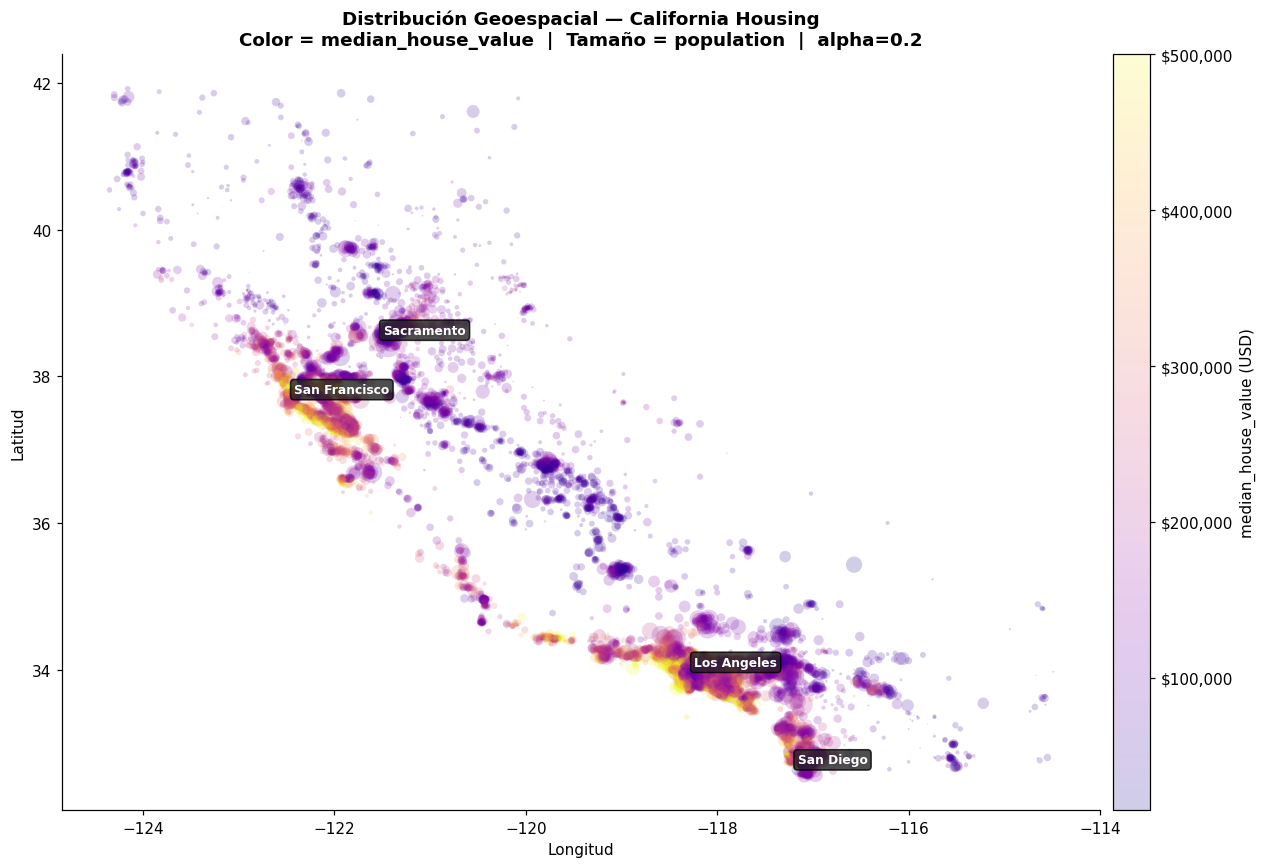

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    x          = housing['longitude'],
    y          = housing['latitude'],
    c          = housing['median_house_value'],
    cmap       = 'plasma',
    alpha      = 0.2,
    s          = housing['population'] / 60,
    linewidths = 0,
)

cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('median_house_value (USD)', fontsize=10)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

cities = {
    'San Francisco': (-122.42, 37.77),
    'Los Angeles'  : (-118.24, 34.05),
    'San Diego'    : (-117.16, 32.72),
    'Sacramento'   : (-121.49, 38.58),
}
for city, (lon, lat) in cities.items():
    ax.annotate(
        city, (lon, lat), fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#222', alpha=0.8),
    )

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(
    'Distribución Geoespacial — California Housing\n'
    'Color = median_house_value  |  Tamaño = population  |  alpha=0.2',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_mapa_geoespacial.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 5. Correlaciones con `median_house_value`

Matriz de correlación con `.corr()` y gráficos de dispersión entre las variables.

In [49]:
# Matriz de correlación completa
corr_matrix = housing.select_dtypes(include=np.number).corr()
corr_matrix.to_csv(REPORTS_DIR / 'eda_correlation_matrix.csv')
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.0000,-0.9240,-0.1109,0.0470,0.0717,0.1062,0.0565,-0.0189,-0.0536
latitude,-0.9240,1.0000,0.0122,-0.0350,-0.0659,-0.1135,-0.0698,-0.0765,-0.1383
housing_median_age,-0.1109,0.0122,1.0000,-0.3591,-0.3156,-0.3018,-0.2977,-0.1260,0.1028
total_rooms,0.0470,-0.0350,-0.3591,1.0000,0.9298,0.8620,0.9147,0.1941,0.1327
total_bedrooms,0.0717,-0.0659,-0.3156,0.9298,1.0000,0.8854,0.9787,-0.0088,0.0517
population,0.1062,-0.1135,-0.3018,0.8620,0.8854,1.0000,0.9148,0.0016,-0.0235
households,0.0565,-0.0698,-0.2977,0.9147,0.9787,0.9148,1.0000,0.0103,0.0685
median_income,-0.0189,-0.0765,-0.1260,0.1941,-0.0088,0.0016,0.0103,1.0000,0.6878
median_house_value,-0.0536,-0.1383,0.1028,0.1327,0.0517,-0.0235,0.0685,0.6878,1.0000


In [50]:
# Correlaciones con el target ordenadas por valor absoluto
corr_target = (
    corr_matrix['median_house_value']
    .drop('median_house_value')
    .sort_values(ascending=True)
)

print('CORRELACIONES con median_house_value (Pearson):')
print('-' * 55)
for col, val in corr_target.sort_values(key=abs, ascending=False).items():
    bar = '█' * int(abs(val) * 30)
    print(f'  {col:<25}  {val:+.4f}  {bar}')

CORRELACIONES con median_house_value (Pearson):
-------------------------------------------------------
  median_income              +0.6878  ████████████████████
  latitude                   -0.1383  ████
  total_rooms                +0.1327  ███
  housing_median_age         +0.1028  ███
  households                 +0.0685  ██
  longitude                  -0.0536  █
  total_bedrooms             +0.0517  █
  population                 -0.0235  


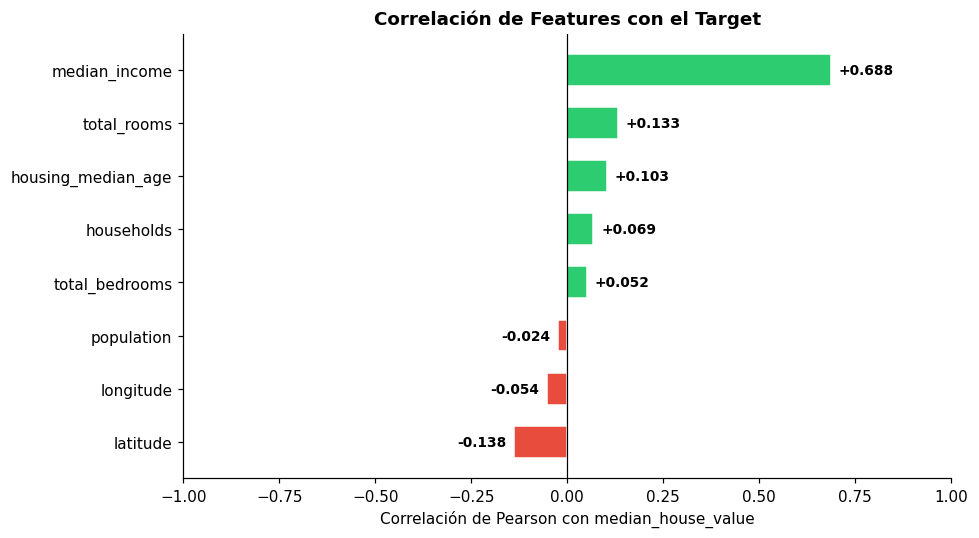

In [51]:
# Barplot de correlaciones con el target
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_target]
bars = ax.barh(
    corr_target.index, corr_target.values,
    color=colors, edgecolor='white', height=0.6
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con median_house_value')
ax.set_title('Correlación de Features con el Target', fontweight='bold')
ax.set_xlim(-1, 1)
for bar, val in zip(bars, corr_target.values):
    ax.text(
        val + (0.02 if val >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}', va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold',
    )
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlaciones_target.png', bbox_inches='tight', dpi=120)
plt.show()

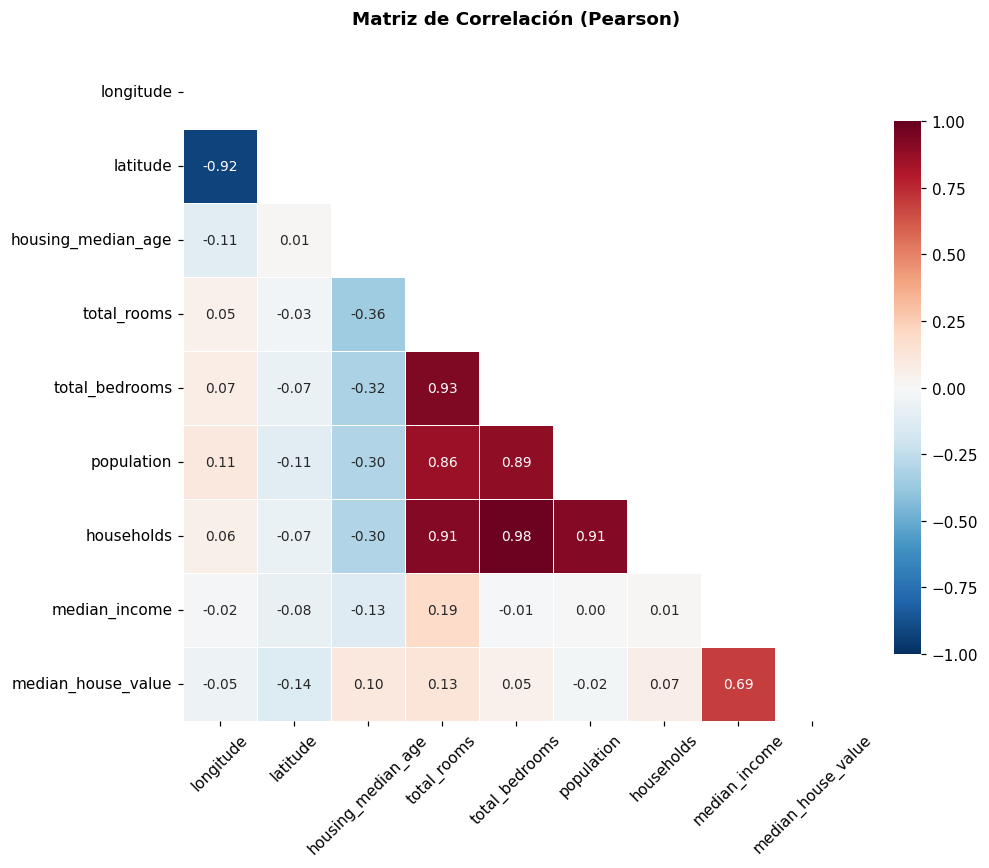

In [52]:
# Heatmap de la matriz completa
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 9},
)
ax.set_title('Matriz de Correlación (Pearson)', fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_heatmap_correlacion.png', bbox_inches='tight', dpi=120)
plt.show()

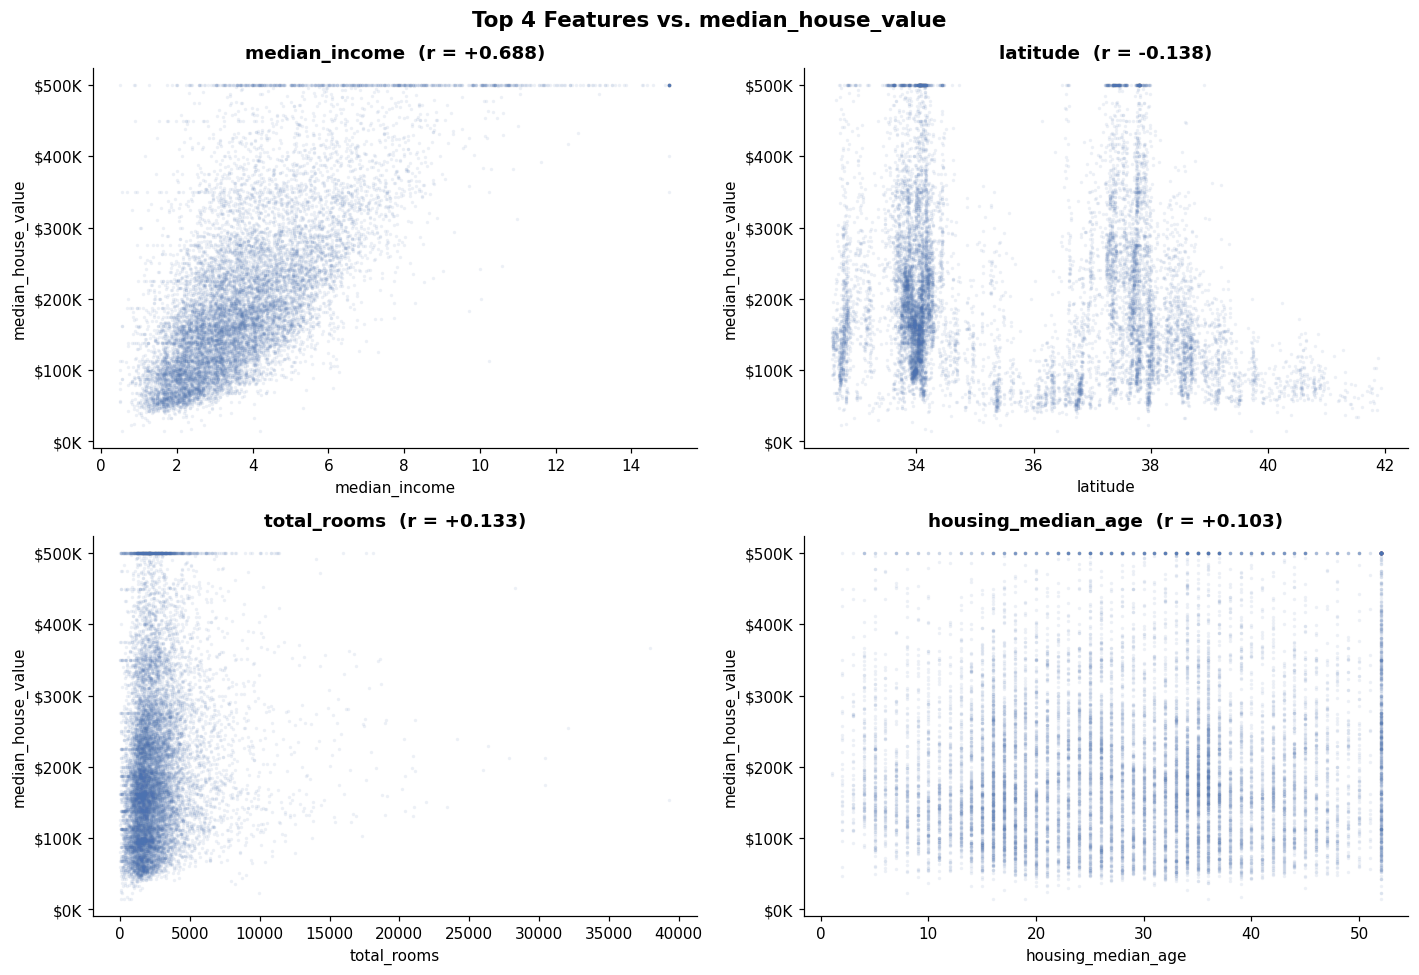

In [53]:
# Scatter plots: top 4 features vs target
top_features = (
    corr_target.abs().sort_values(ascending=False).head(4).index.tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(
        housing[feat], housing['median_house_value'],
        alpha=0.1, s=5, color='#4C72B0', linewidths=0,
    )
    r = corr_matrix.loc[feat, 'median_house_value']
    ax.set_title(f'{feat}  (r = {r:+.3f})', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('median_house_value')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
    )
fig.suptitle('Top 4 Features vs. median_house_value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_scatter_top_features.png', bbox_inches='tight', dpi=120)
plt.show()

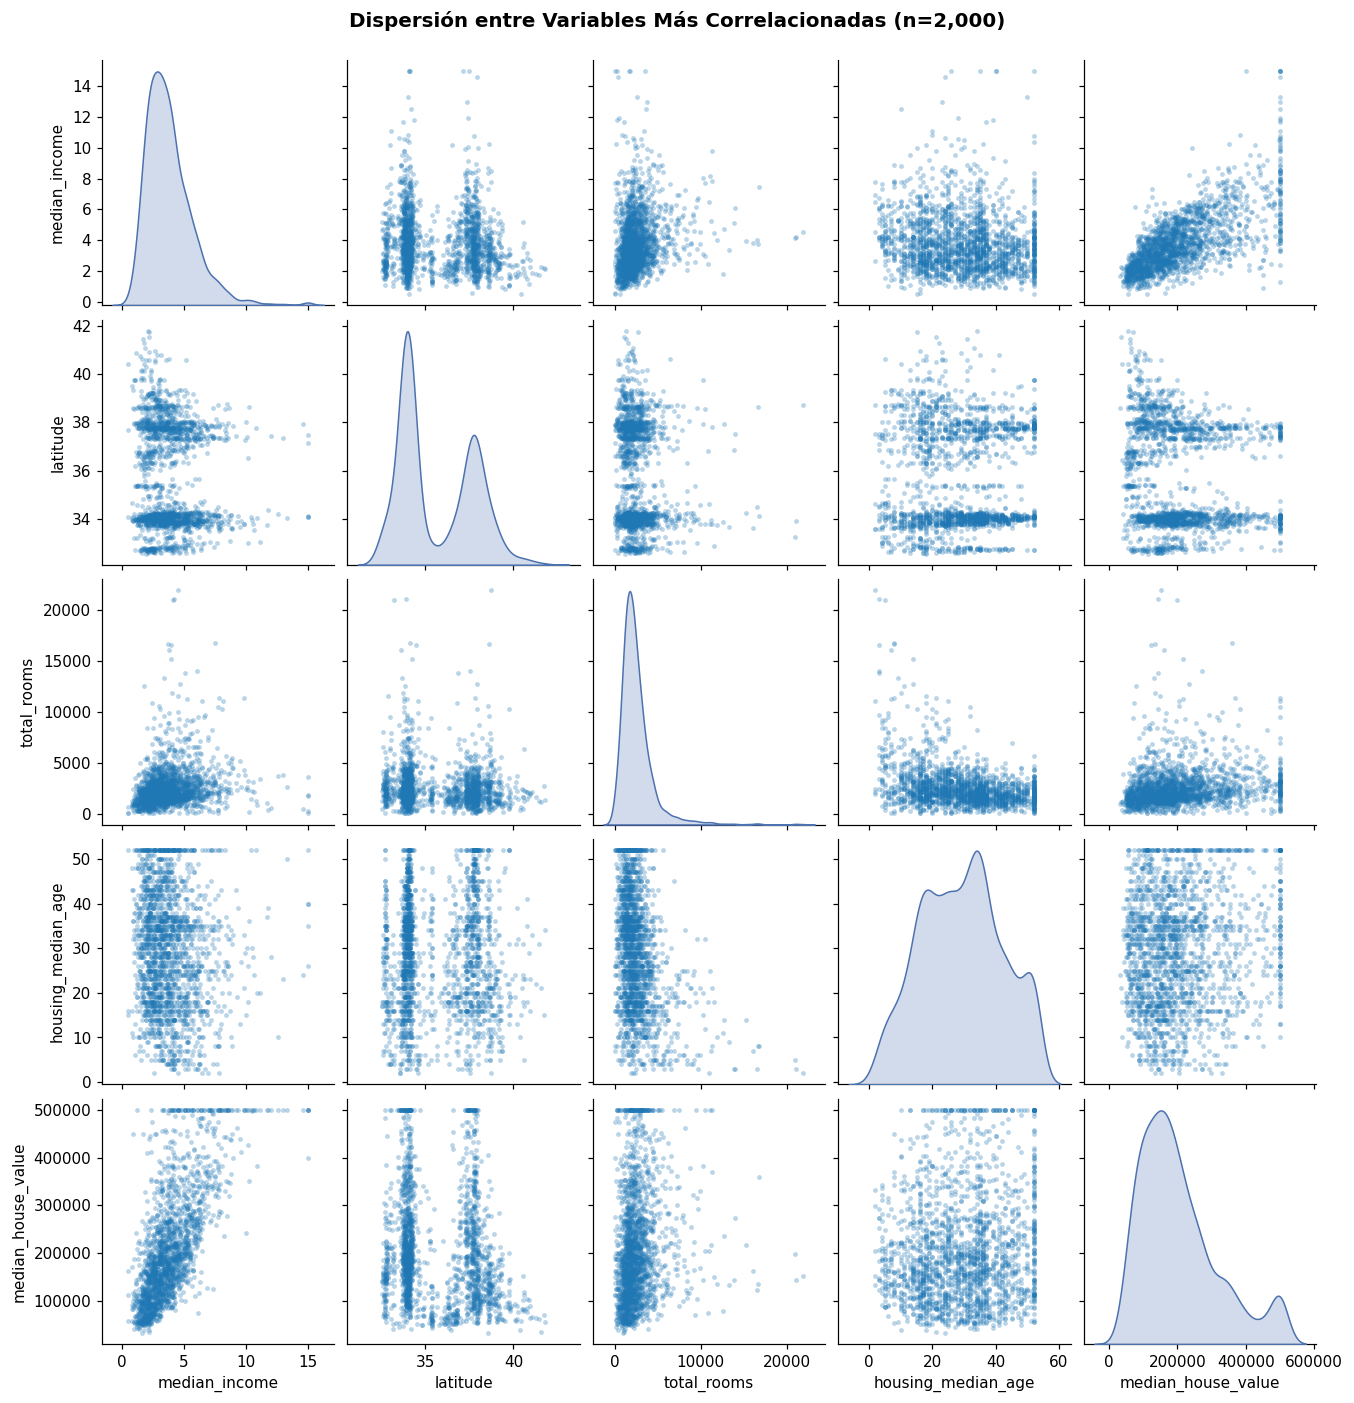

In [54]:
# Pairplot entre las variables más correlacionadas (muestra n=2000)
selected = top_features + ['median_house_value']
sample   = housing[selected].sample(2000, random_state=42)

g = sns.pairplot(
    sample,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10, 'linewidth': 0},
    diag_kws={'color': '#4C72B0', 'fill': True},
)
g.figure.suptitle(
    'Dispersión entre Variables Más Correlacionadas (n=2,000)',
    y=1.02, fontsize=13, fontweight='bold',
)
plt.savefig(FIGURES_DIR / 'eda_pairplot.png', bbox_inches='tight', dpi=100)
plt.show()

---
## 6. Conclusiones

### Calidad del Dataset

| Dimensión | Hallazgo |
|-----------|----------|
| **Completitud** | `total_bedrooms` tiene 207 valores faltantes (1%). El resto de columnas está completo. |
| **Consistencia** | Sin filas duplicadas. `ocean_proximity` es la única variable categórica con 5 niveles válidos. |
| **Precisión** | `total_rooms`, `total_bedrooms` y `population` presentan outliers severos (>3% fuera del rango IQR). |
| **Sensibilidad** | `median_house_value` está censurado en $500,001: el ~1.8% de registros tiene ese valor exacto aunque el precio real sea mayor. |

### Hallazgos de Negocio

**1. El ingreso del vecindario predice el precio mejor que cualquier otra variable.**
La correlación entre `median_income` y `median_house_value` es la más alta (r ≈ 0.69).
A mayor poder adquisitivo de la zona, mayor es el valor de las viviendas.

**2. La ubicación geográfica es tan importante como el ingreso.**
El mapa de dispersión muestra con claridad que las zonas costeras concentran los precios más altos.
Las zonas del interior de California presentan precios significativamente menores.
`latitude` y `longitude` deben incluirse en el modelo.

**3. La proximidad al océano genera una prima de precio sustancial.**
Las viviendas en islas (`ISLAND`) cuestan en promedio más del doble que las del interior (`INLAND`).
Las propiedades a menos de 1 hora del océano superan en un ~40% a las zonas inland.

**4. Las variables de tamaño en valores absolutos son pobres predictores directos.**
`total_rooms` y `total_bedrooms` como totales por bloque dependen del número de hogares.
Su utilidad mejora cuando se expresan como ratios: habitaciones por hogar, proporción de dormitorios.

**5. Varias variables presentan distribuciones fuertemente sesgadas.**
`total_rooms`, `total_bedrooms`, `population` y `households` tienen skewness mayor a 1.
Esto se tendrá en cuenta al preparar las features para el modelado.